# **Program 1: Write a program to implement KNearestNeighbors and import data from any CSV file.**

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

In [2]:
# Load dataset from URL
url = "https://github.com/mubaris/potential-enigma/raw/master/headbrain.csv"
data = pd.read_csv(url)

print("First few rows of the dataset :")
print(data.head())

First few rows of the dataset :
   Gender  Age Range  Head Size(cm^3)  Brain Weight(grams)
0       1          1             4512                 1530
1       1          1             3738                 1297
2       1          1             4261                 1335
3       1          1             3777                 1282
4       1          1             4177                 1590



Mean Squared Error: 6225.72839506173

Comparison of Actual and Predicted values :
   Actual    Predicted
0    1275  1246.000000
1    1405  1428.333333
2    1320  1281.666667
3    1125  1141.666667
4    1400  1354.000000


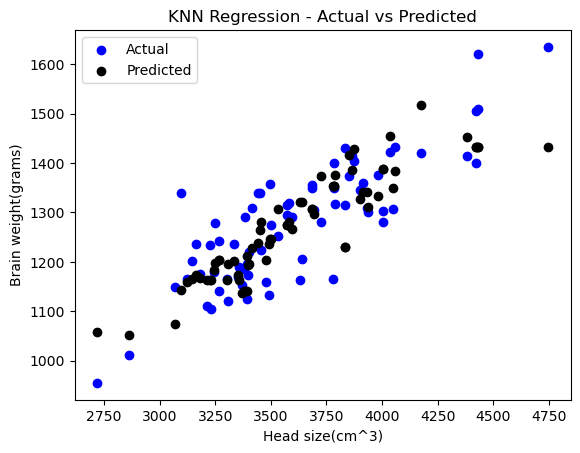

In [3]:
# Extract features and target variable
X = data['Head Size(cm^3)'].values.reshape(-1, 1)
Y = data['Brain Weight(grams)'].values.reshape(-1, 1)

# Split data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Create and train KNN Regressor
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train, Y_train)

# Predict on test set
Y_pred = knn.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(Y_test, Y_pred)
print("\nMean Squared Error:", mse)

# Create comparison DataFrame
comparison = pd.DataFrame({
    'Actual': Y_test.flatten(),
    'Predicted': Y_pred.flatten()
})
print("\nComparison of Actual and Predicted values :")
print(comparison.head())

# Plot results
plt.scatter(X_test, Y_test, color='blue', label='Actual')
plt.scatter(X_test, Y_pred, color='black', label='Predicted')
plt.title('KNN Regression - Actual vs Predicted')
plt.xlabel('Head size(cm^3)')
plt.ylabel('Brain weight(grams)')
plt.legend()
plt.show()